In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("../data/processed/cleaned_data_v2.csv")

In [19]:
df.shape

(50000, 33)

In [20]:
df.head()

,transaction_date,transaction_time,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,cust_txn_count,cust_fraud_count,cust_fraud_rate,cust_avg_amt,amt_deviation,amt_ratio,device_count,new_device_flag,merchant_fraud_rate,otp_risk,combined_risk,is_fraud
0,2024-01-01,23:51:00,10158.89,CARD,0,Gaming,0.162148,0.119578,1,4163.76,9,1,0,OTP,0.674188,2,4,0.057505,23,0,0,0,0.0,0.0,0.000000,10158.890000,10158.890000,0.0,1,0.0,0.325812,0.065162,0
1,2024-01-01,23:35:00,556.63,UPI,0,Fashion,0.041787,0.841375,0,3294.64,2,0,0,3DS,0.960875,1,4,0.063596,23,0,0,1,0.0,0.0,10158.890000,-9602.260000,0.054787,2.0,1,0.0,0.039125,0.007825,0
2,2024-01-10,19:49:00,15754.57,UPI,0,Grocery,0.774662,0.718447,8,5077.26,9,0,1,OTP,0.604628,2,1,0.053729,19,2,0,2,0.0,0.0,5357.760000,10396.810000,2.939966,3.0,1,0.0,0.395372,0.079074,0
3,2024-01-20,13:00:00,6095.68,CARD,0,Fashion,0.259900,0.069586,2,1187.30,10,0,0,NONE,0.968040,2,0,0.004334,13,5,1,3,0.0,0.0,8823.363333,-2727.683333,0.690778,4.0,1,0.0,0.031960,0.006392,0
4,2024-01-23,10:37:00,15324.24,UPI,0,Gaming,0.376711,0.286630,7,10936.02,8,0,0,OTP,0.711123,1,3,0.131218,10,1,0,4,0.0,0.0,8141.442500,7182.797500,1.882020,5.0,1,0.0,0.288877,0.057775,0


In [21]:
df['new_device_flag'].value_counts()

new_device_flag
1    49997
0        3
Name: count, dtype: int64

In [22]:
# The 'new_device_flag' column is just has a single value so dropping it 

df.drop(columns='new_device_flag',inplace=True,axis=1)

In [23]:
# Here the date and time columns are irrelevant it will misleading for feature selection process

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day

df = df.drop(columns=['transaction_time'])

In [24]:
# Changing the 'is_fraud' column position

col = df.pop('is_fraud')
df['is_fraud'] = col

In [ ]:
df.to_csv("../data/processed/cleaned_data_v3.csv", index=False)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   transaction_date                50000 non-null  datetime64[ns]
 1   amount                          50000 non-null  float64       
 2   payment_method                  50000 non-null  object        
 3   is_international                50000 non-null  int64         
 4   merchant_category               50000 non-null  object        
 5   ip_address_risk_score           50000 non-null  float64       
 6   device_trust_score              50000 non-null  float64       
 7   txn_count_last_24h              50000 non-null  int64         
 8   avg_amount_last_24h             50000 non-null  float64       
 9   merchant_diversity_last_7d      50000 non-null  int64         
 10  device_change_flag              50000 non-null  int64         
 11  lo

<Axes: >

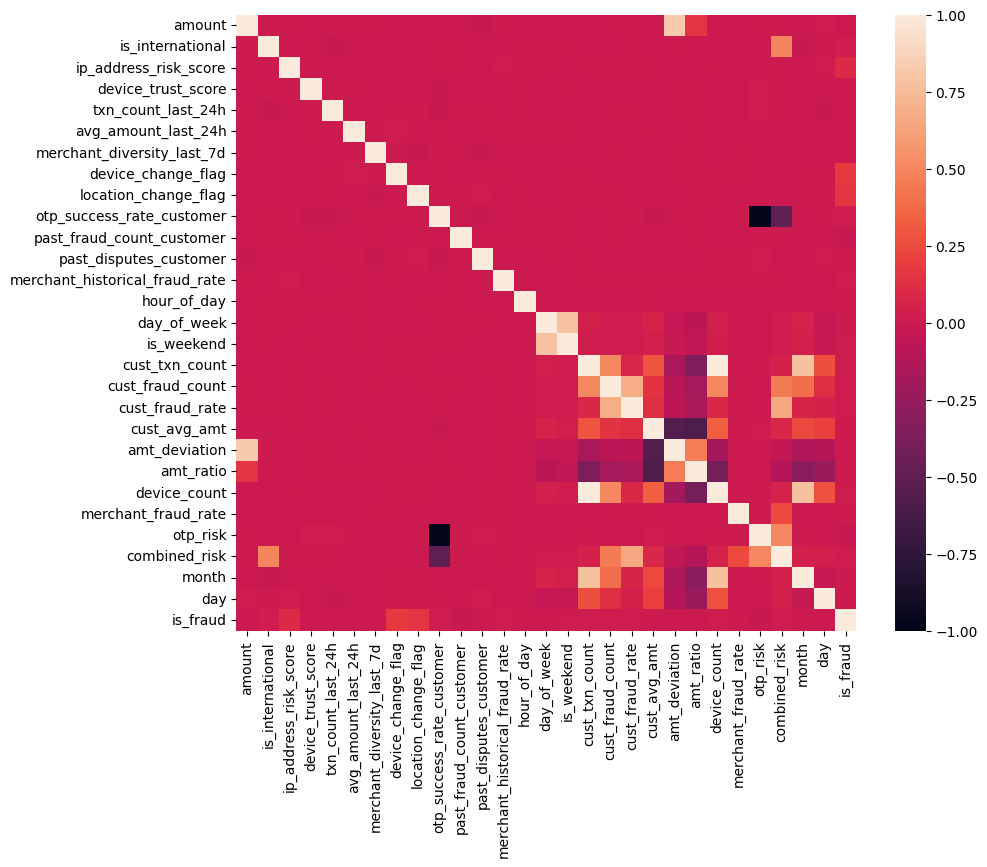

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['int','float']).corr())

In [28]:
df.select_dtypes(include=['int','float']).corr()['is_fraud'].sort_values(ascending=False)

is_fraud                          1.000000
device_change_flag                0.179381
location_change_flag              0.153269
ip_address_risk_score             0.097142
is_international                  0.017377
merchant_historical_fraud_rate    0.015068
cust_fraud_count                  0.012343
combined_risk                     0.011724
cust_fraud_rate                   0.010693
is_weekend                        0.009500
otp_success_rate_customer         0.009362
cust_txn_count                    0.009183
device_count                      0.009116
month                             0.007065
cust_avg_amt                      0.004724
hour_of_day                       0.004013
merchant_fraud_rate               0.003092
day_of_week                       0.002144
past_disputes_customer            0.001084
txn_count_last_24h               -0.001403
device_trust_score               -0.002705
avg_amount_last_24h              -0.003423
amt_ratio                        -0.004029
amount     

In [29]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

data = df.copy()

# 1. Ensure date is in datetime format before splitting
data['transaction_date'] = pd.to_datetime(data['transaction_date'])


# 2. Split the data FIRST (prevents leakage)
train_raw = data[data['transaction_date'] < '2024-03-01'].copy()
test_raw  = data[data['transaction_date'] >= '2024-03-01'].copy()

# 3. Identify categorical columns
categorical_cols = train_raw.select_dtypes(['object']).columns.to_list()
if 'transaction_date' in categorical_cols:
    categorical_cols.remove('transaction_date')

# 4. Initialize and Fit the Encoder ONLY on Train

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit on train, transform both
train_raw[categorical_cols] = oe.fit_transform(train_raw[categorical_cols])
test_raw[categorical_cols] = oe.transform(test_raw[categorical_cols])

# 5. Drop the date and separate X and y
X_train = train_raw.drop(columns=['transaction_date', 'is_fraud'])
y_train = train_raw['is_fraud']

X_test = test_raw.drop(columns=['transaction_date', 'is_fraud'])
y_test = test_raw['is_fraud']

In [30]:
X_train

,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,cust_txn_count,cust_fraud_count,cust_fraud_rate,cust_avg_amt,amt_deviation,amt_ratio,device_count,merchant_fraud_rate,otp_risk,combined_risk,month,day
0,10158.89,0.0,0,2.0,0.162148,0.119578,1,4163.76,9,1,0,2.0,0.674188,2,4,0.057505,23,0,0,0,0.0,0.000000,0.000000,10158.890000,10158.890000,0.0,0.000000,0.325812,0.065162,1,1
1,556.63,2.0,0,1.0,0.041787,0.841375,0,3294.64,2,0,0,0.0,0.960875,1,4,0.063596,23,0,0,1,0.0,0.000000,10158.890000,-9602.260000,0.054787,2.0,0.000000,0.039125,0.007825,1,1
2,15754.57,2.0,0,3.0,0.774662,0.718447,8,5077.26,9,0,1,2.0,0.604628,2,1,0.053729,19,2,0,2,0.0,0.000000,5357.760000,10396.810000,2.939966,3.0,0.000000,0.395372,0.079074,1,10
3,6095.68,0.0,0,1.0,0.259900,0.069586,2,1187.30,10,0,0,1.0,0.968040,2,0,0.004334,13,5,1,3,0.0,0.000000,8823.363333,-2727.683333,0.690778,4.0,0.000000,0.031960,0.006392,1,20
4,15324.24,2.0,0,2.0,0.376711,0.286630,7,10936.02,8,0,0,2.0,0.711123,1,3,0.131218,10,1,0,4,0.0,0.000000,8141.442500,7182.797500,1.882020,5.0,0.000000,0.288877,0.057775,1,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49988,1443.16,0.0,0,3.0,0.826829,0.837350,7,7386.05,7,0,0,3.0,0.658128,1,3,0.063661,23,1,0,5,0.0,0.000000,15258.628000,-13815.468000,0.094574,6.0,0.125000,0.341872,0.105874,1,30
49989,7034.11,3.0,0,5.0,0.467440,0.383128,2,1036.59,1,0,0,2.0,0.496117,0,4,0.100995,18,5,1,6,1.0,0.166667,12956.050000,-5921.940000,0.542879,7.0,0.093567,0.503883,0.178847,2,3
49990,15835.23,0.0,0,5.0,0.202953,0.029018,8,9976.89,9,0,0,2.0,0.688251,0,0,0.071319,5,0,0,7,1.0,0.142857,12110.058571,3725.171429,1.307502,8.0,0.101796,0.311749,0.135746,2,12
49991,4891.32,1.0,0,2.0,0.414331,0.443300,3,7101.47,11,0,0,0.0,0.721530,0,2,0.103789,17,6,1,8,1.0,0.125000,12575.705000,-7684.385000,0.388919,9.0,0.115385,0.278470,0.127809,2,25


In [31]:
y_train

0        0
1        0
2        0
3        0
4        0
        ..
49988    1
49989    0
49990    0
49991    0
49992    0
Name: is_fraud, Length: 33407, dtype: int64

## Using different technique to select the best features from the data

## Technique 1 - Correlation Analysis

<Axes: >

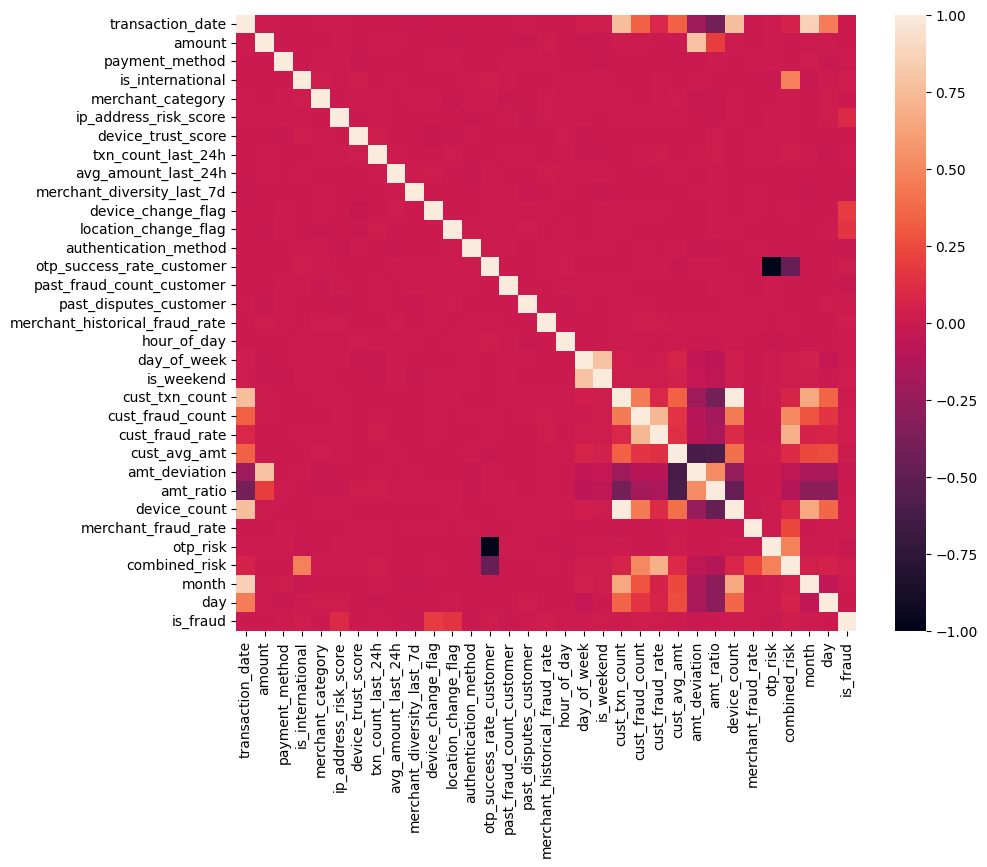

In [32]:
plt.figure(figsize=(10,8))
sns.heatmap(train_raw.corr())

In [33]:
fi_df1 = fi_df1 = train_raw.select_dtypes(include=['int','float']).corr()['is_fraud'].sort_values(ascending=False).iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','is_fraud':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,device_change_flag,0.180422
1,location_change_flag,0.148878
2,ip_address_risk_score,0.097218
3,is_international,0.019025
4,merchant_historical_fraud_rate,0.016561
5,is_weekend,0.015574
6,combined_risk,0.012121
7,cust_fraud_count,0.011067
8,cust_fraud_rate,0.010997
9,otp_success_rate_customer,0.010800


## Technique 2 - Random Forest Feature Importance

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest Classifier on encoded data
rf_label = RandomForestClassifier(n_estimators=100, random_state=42)
rf_label.fit(X_train, y_train)

# Extract feature importance scores for encoded data
fi_df2 = pd.DataFrame({
    'feature': X_train.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
4,ip_address_risk_score,0.064840
15,merchant_historical_fraud_rate,0.055485
5,device_trust_score,0.055379
7,avg_amount_last_24h,0.054579
28,combined_risk,0.051781
0,amount,0.050688
23,amt_deviation,0.049228
24,amt_ratio,0.048563
26,merchant_fraud_rate,0.048216
27,otp_risk,0.047982


## Technique 3 - Gradient Boosting Feature importance

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

# Train a Random Forest Classifier on encoded data
gb_label = GradientBoostingClassifier()
gb_label.fit(X_train, y_train)

# Extract feature importance scores for encoded data
fi_df3 = pd.DataFrame({
    'feature': X_train.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
9,device_change_flag,0.342406
10,location_change_flag,0.239377
4,ip_address_risk_score,0.150433
15,merchant_historical_fraud_rate,0.038713
28,combined_risk,0.031127
5,device_trust_score,0.022964
24,amt_ratio,0.021064
7,avg_amount_last_24h,0.020040
23,amt_deviation,0.019481
22,cust_avg_amt,0.016607


## Technique 4 - Permutation Importance

In [36]:
from sklearn.inspection import permutation_importance

# Train a Random Forest Classifier on encoded data
rf_label = RandomForestClassifier(n_estimators=100, random_state=42)
rf_label.fit(X_train, y_train)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test, y_test, n_repeats=30, random_state=42, scoring='roc_auc')

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_train.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
9,device_change_flag,7.197452e-02
10,location_change_flag,6.441835e-02
4,ip_address_risk_score,3.416940e-02
27,otp_risk,9.066251e-03
12,otp_success_rate_customer,9.051874e-03
22,cust_avg_amt,2.956579e-03
28,combined_risk,2.634574e-03
23,amt_deviation,2.552683e-03
24,amt_ratio,2.311781e-03
13,past_fraud_count_customer,1.204059e-03


## Technique 5 - LASSO

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Logistic Regression with L1 penalty (Lasso-style)
log_reg = LogisticRegression(
    penalty='l1',
    solver='liblinear',   # required for l1
    C=1.0,                # inverse of regularization strength
    random_state=42
)

log_reg.fit(X_scaled, y_train)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_train.columns,
    'lasso_coeff': log_reg.coef_[0]
})


fi_df5 = fi_df5.sort_values(by='lasso_coeff', key=abs, ascending=False)
fi_df5

c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\mabin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature,lasso_coeff
9,device_change_flag,0.421314
10,location_change_flag,0.383629
4,ip_address_risk_score,0.358177
18,is_weekend,0.103449
17,day_of_week,-0.062372
2,is_international,0.057468
15,merchant_historical_fraud_rate,0.055193
30,day,-0.044685
13,past_fraud_count_customer,-0.039048
8,merchant_diversity_last_7d,-0.029360


## Technique 6 - RFE

In [38]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestClassifier()

# Apply RFE on the encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_train.shape[1], step=1)
selector_label = selector_label.fit(X_train, y_train)

# Get the selected features based on RFE
selected_features = X_train.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
4,ip_address_risk_score,0.065760
15,merchant_historical_fraud_rate,0.055210
7,avg_amount_last_24h,0.054607
5,device_trust_score,0.054327
28,combined_risk,0.052582
0,amount,0.050669
23,amt_deviation,0.050152
24,amt_ratio,0.048643
12,otp_success_rate_customer,0.048510
26,merchant_fraud_rate,0.048020


## Technique 7 - Logistic Regression Weights

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Logistic Regression (no regularization removal)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

log_reg.fit(X_scaled, y_train)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_train.columns,
    'reg_coeffs': log_reg.coef_[0]
})

# Sort by absolute importance
fi_df7 = fi_df7.reindex(fi_df7.reg_coeffs.abs().sort_values(ascending=False).index)

fi_df7

,feature,reg_coeffs
9,device_change_flag,0.421403
10,location_change_flag,0.383644
4,ip_address_risk_score,0.358320
18,is_weekend,0.104715
17,day_of_week,-0.063704
15,merchant_historical_fraud_rate,0.055521
2,is_international,0.051954
30,day,-0.046634
13,past_fraud_count_customer,-0.039423
29,month,-0.030870


In [40]:
final_fi_df = fi_df2.merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').set_index('feature')

In [41]:
final_fi_df

,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs
feature,,,,,,
ip_address_risk_score,0.064840,0.150433,3.416940e-02,0.358177,0.065760,0.358320
merchant_historical_fraud_rate,0.055485,0.038713,3.950533e-04,0.055193,0.055210,0.055521
device_trust_score,0.055379,0.022964,3.970126e-04,-0.002700,0.054327,-0.003116
avg_amount_last_24h,0.054579,0.020040,5.112754e-04,-0.004954,0.054607,-0.005434
combined_risk,0.051781,0.031127,2.634574e-03,0.006652,0.052582,0.018836
amount,0.050688,0.006318,6.407699e-04,0.000000,0.050669,-0.001715
amt_deviation,0.049228,0.019481,2.552683e-03,-0.014656,0.050152,-0.014057
amt_ratio,0.048563,0.021064,2.311781e-03,0.004777,0.048643,0.007127
merchant_fraud_rate,0.048216,0.007983,2.464697e-04,0.005390,0.048020,0.002913


In [42]:
# normalize the score
final_fi_df['lasso_coeff'] = final_fi_df['lasso_coeff'].abs()
final_fi_df['reg_coeffs'] = final_fi_df['reg_coeffs'].abs()
# final_fi_df['corr_coeff'] = final_fi_df['corr_coeff'].abs()

final_fi_df = final_fi_df.rank(ascending=False)

In [43]:
final_fi_df.mean(axis=1).sort_values()

feature
ip_address_risk_score              2.333333
device_change_flag                 5.666667
merchant_historical_fraud_rate     6.333333
location_change_flag               8.166667
combined_risk                     10.000000
otp_success_rate_customer         10.666667
otp_risk                          11.166667
amt_deviation                     11.500000
day                               11.833333
cust_avg_amt                      12.000000
avg_amount_last_24h               12.666667
amt_ratio                         13.000000
device_trust_score                14.166667
merchant_diversity_last_7d        16.666667
amount                            16.916667
hour_of_day                       17.000000
day_of_week                       17.000000
merchant_fraud_rate               17.500000
cust_txn_count                    17.500000
past_fraud_count_customer         18.500000
is_international                  19.000000
is_weekend                        19.833333
authentication_method   

### Summary

Following the feature engineering phase, a feature selection process was conducted to identify and eliminate variables that contribute minimal predictive value to the target variable. Removing such features helps simplify the model, improve interpretability, and potentially reduce multicollinearity and overfitting.

To evaluate the impact of feature removal, a baseline Random Forest classifier was initially trained using all available features. Model performance was assessed using appropriate classification metrics such as Recall, F1-score, and ROC-AUC, given the imbalanced nature of the fraud detection problem.

Subsequently, low-importance or redundant features were removed based on feature importance analysis. The model was retrained using the reduced feature set, and performance metrics were compared against the baseline model. If the removal of specific features resulted in a significant decline in performance, those features were retained. Otherwise, they were permanently excluded from the dataset.

This iterative approach ensured that only meaningful and high-impact variables were retained, thereby improving model efficiency without compromising fraud detection capability.

In [44]:
X_train

,amount,payment_method,is_international,merchant_category,ip_address_risk_score,device_trust_score,txn_count_last_24h,avg_amount_last_24h,merchant_diversity_last_7d,device_change_flag,location_change_flag,authentication_method,otp_success_rate_customer,past_fraud_count_customer,past_disputes_customer,merchant_historical_fraud_rate,hour_of_day,day_of_week,is_weekend,cust_txn_count,cust_fraud_count,cust_fraud_rate,cust_avg_amt,amt_deviation,amt_ratio,device_count,merchant_fraud_rate,otp_risk,combined_risk,month,day
0,10158.89,0.0,0,2.0,0.162148,0.119578,1,4163.76,9,1,0,2.0,0.674188,2,4,0.057505,23,0,0,0,0.0,0.000000,0.000000,10158.890000,10158.890000,0.0,0.000000,0.325812,0.065162,1,1
1,556.63,2.0,0,1.0,0.041787,0.841375,0,3294.64,2,0,0,0.0,0.960875,1,4,0.063596,23,0,0,1,0.0,0.000000,10158.890000,-9602.260000,0.054787,2.0,0.000000,0.039125,0.007825,1,1
2,15754.57,2.0,0,3.0,0.774662,0.718447,8,5077.26,9,0,1,2.0,0.604628,2,1,0.053729,19,2,0,2,0.0,0.000000,5357.760000,10396.810000,2.939966,3.0,0.000000,0.395372,0.079074,1,10
3,6095.68,0.0,0,1.0,0.259900,0.069586,2,1187.30,10,0,0,1.0,0.968040,2,0,0.004334,13,5,1,3,0.0,0.000000,8823.363333,-2727.683333,0.690778,4.0,0.000000,0.031960,0.006392,1,20
4,15324.24,2.0,0,2.0,0.376711,0.286630,7,10936.02,8,0,0,2.0,0.711123,1,3,0.131218,10,1,0,4,0.0,0.000000,8141.442500,7182.797500,1.882020,5.0,0.000000,0.288877,0.057775,1,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49988,1443.16,0.0,0,3.0,0.826829,0.837350,7,7386.05,7,0,0,3.0,0.658128,1,3,0.063661,23,1,0,5,0.0,0.000000,15258.628000,-13815.468000,0.094574,6.0,0.125000,0.341872,0.105874,1,30
49989,7034.11,3.0,0,5.0,0.467440,0.383128,2,1036.59,1,0,0,2.0,0.496117,0,4,0.100995,18,5,1,6,1.0,0.166667,12956.050000,-5921.940000,0.542879,7.0,0.093567,0.503883,0.178847,2,3
49990,15835.23,0.0,0,5.0,0.202953,0.029018,8,9976.89,9,0,0,2.0,0.688251,0,0,0.071319,5,0,0,7,1.0,0.142857,12110.058571,3725.171429,1.307502,8.0,0.101796,0.311749,0.135746,2,12
49991,4891.32,1.0,0,2.0,0.414331,0.443300,3,7101.47,11,0,0,0.0,0.721530,0,2,0.103789,17,6,1,8,1.0,0.125000,12575.705000,-7684.385000,0.388919,9.0,0.115385,0.278470,0.127809,2,25


In [45]:
y_train

0        0
1        0
2        0
3        0
4        0
        ..
49988    1
49989    0
49990    0
49991    0
49992    0
Name: is_fraud, Length: 33407, dtype: int64

In [47]:
X_train.shape

(33407, 31)

In [48]:
y_train.shape

(33407,)